Generate a PCA before and after cohort batch correction for the thesis 

## PCA Before batch correction

In [21]:
from typing import Dict, Tuple

import anndata as ad
import pandas as pd

from methyltrain.config.loader import load_config
from methyltrain.fs.layout import CohortLayout

from methyltrain.api.steps import (
    cohort_batch_correction, 
    load_processed_project,
    aggregate_cohort,
    cohort_batch_correction
)

projects = [
    "../data/processed/TCGA-CESC_adata.h5ad",
    "../data/processed/TCGA-CHOL_adata.h5ad",
    "../data/processed/TCGA-COAD_adata.h5ad",
    "../data/processed/TCGA-ESCA_adata.h5ad",
    "../data/processed/TCGA-GBM_adata.h5ad",
    "../data/processed/TCGA-KIRP_adata.h5ad",
    "../data/processed/TCGA-LUAD_adata.h5ad",
    "../data/processed/TCGA-OV_adata.h5ad",
    "../data/processed/TCGA-PAAD_adata.h5ad",
    "../data/processed/TCGA-UVM_adata.h5ad",
]

layout = CohortLayout(
    cohort_name = "pancancer",
    root_dir = "../data",
    project_list = projects,
    cohort_adata = "../data/processed/pancancer_cohort_adata.h5ad",
    train_adata = "../data/processed/pancancer_train_adata.h5ad",
    val_adata = "../data/processed/pancancer_val_adata.h5ad",
    test_adata = "../data/processed/pancancer_test_adata.h5ad"
)

config = load_config(
    "../config/pancancer_config.yaml"
)

# Ensure directories exist
layout.initialize()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Load each processed project AnnData object 
project_adatas = [load_processed_project(path) 
                  for path in layout.project_list]

# Aggregate the projects into a cohort AnnData object
cohort_adata = aggregate_cohort(project_adatas, layout)

In [23]:
import scanpy as sc
import numpy as np

### PCA Coloured by Project

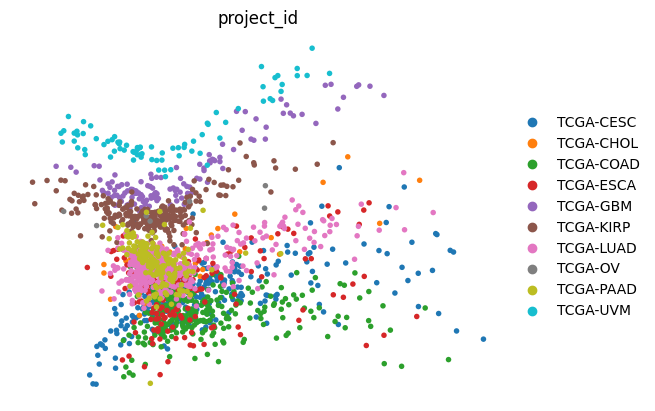

In [24]:
# Optional: subset to top variable CpGs (stabilizes PCA)
sc.pp.highly_variable_genes(cohort_adata, n_top_genes=5000, flavor="seurat")

# Subset to variable features
adata_pca = cohort_adata[:, cohort_adata.var['highly_variable']].copy()

# Standardize features (zero mean, unit variance)
sc.pp.scale(adata_pca, max_value=10)
sc.tl.pca(adata_pca, n_comps=10)

sc.pl.pca(
    adata_pca,
    color="project_id",
    components=["1,2"],
    frameon=False
)

### PCA Coloured by Batch

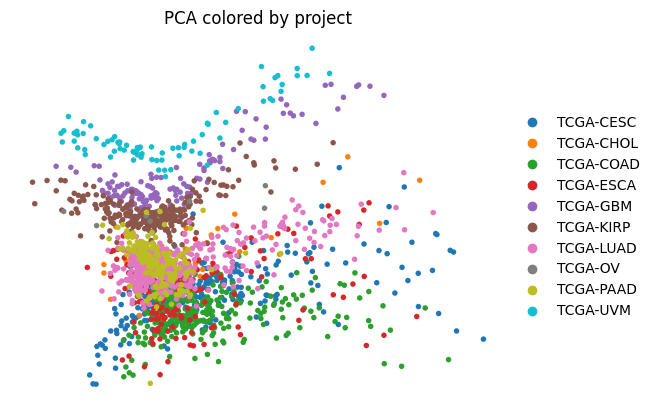

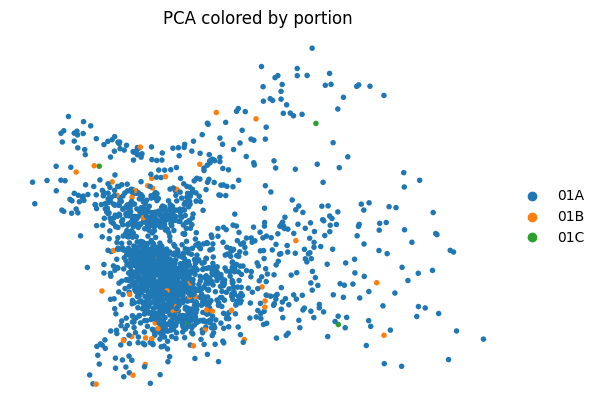

Variance fraction explained by project: 0.6064228
Variance fraction explained by portion: 0.1461063


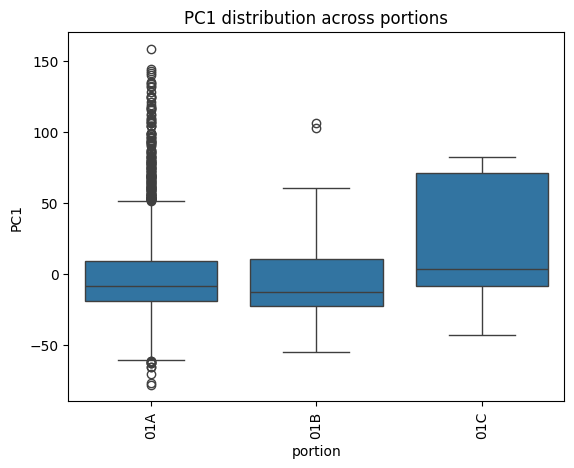

In [25]:
import scanpy as sc
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. Subset to highly variable CpGs
# --------------------------
adata_var = cohort_adata[:, cohort_adata.var['highly_variable']].copy()

# Standardize features
sc.pp.scale(adata_var, max_value=10)

# Extract portion
adata_var.obs['portion'] = adata_var.obs['batch_id'].str.split('-').str[0]

# --------------------------
# 2. PCA
# --------------------------
sc.tl.pca(adata_var, n_comps=10)

# Store PCA in DataFrame for analysis
pcs_df = pd.DataFrame(
    adata_var.obsm['X_pca'],
    index=adata_var.obs_names,
    columns=[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]
)
pcs_df = pcs_df.join(adata_var.obs[['batch_id', 'project_id']])

# --------------------------
# 3. Aggregate batches within project (optional)
# --------------------------
# Extract portion from batch_id (portion-plate)
pcs_df['portion'] = pcs_df['batch_id'].str.split('-').str[0]

# --------------------------
# 4. Visualize PCA colored by project and portion
# --------------------------
sc.pl.pca(
    adata_var,
    color='project_id',
    components=['1,2'],
    frameon=False,
    title="PCA colored by project"
)

# Portion overlay (aggregated across all projects)
sc.pl.pca(
    adata_var,
    color='portion',
    components=['1,2'],
    frameon=False,
    title="PCA colored by portion"
)

# --------------------------
# 5. Variance explained by batch vs project (quantitative)
# --------------------------
pcs_numeric = pcs_df[[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]]

def fraction_variance(df_numeric, factor_series):
    """Fraction of variance in numeric PCs explained by a categorical factor."""
    grouped = df_numeric.groupby(factor_series).mean()
    return grouped.var().sum() / df_numeric.var().sum()

# Example usage:
fv_project = fraction_variance(pcs_numeric, pcs_df['project_id'])
fv_portion = fraction_variance(pcs_numeric, pcs_df['portion'])

print("Variance fraction explained by project:", fv_project)
print("Variance fraction explained by portion:", fv_portion)

# --------------------------
# 6. Optional: PC distributions per portion (boxplot)
# --------------------------
sns.boxplot(x='portion', y='PC1', data=pcs_df)
plt.xticks(rotation=90)
plt.title("PC1 distribution across portions")
plt.show()


## PCA After Batch Correction

In [26]:
# Perform batch effect correction across datasets if toggled
cohort_adata = cohort_batch_correction(cohort_adata, config)

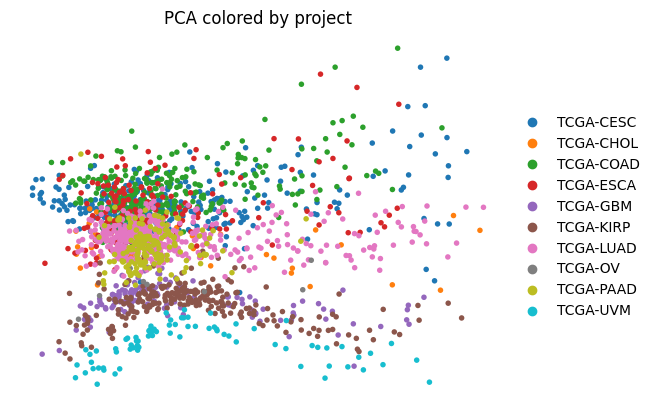

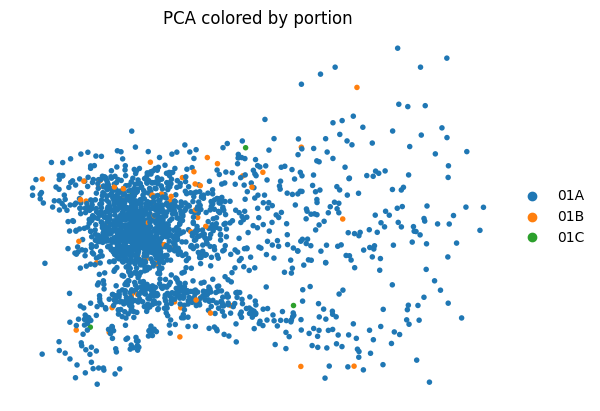

Variance fraction explained by project: 0.40229434
Variance fraction explained by portion: 0.04017609


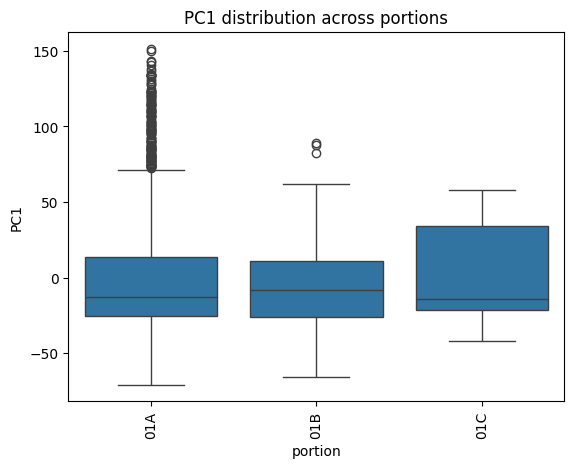

In [27]:
import scanpy as sc
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. Subset to highly variable CpGs
# --------------------------
sc.pp.highly_variable_genes(cohort_adata, n_top_genes=5000, flavor="seurat")
adata_var = cohort_adata[:, cohort_adata.var['highly_variable']].copy()

# Standardize features
sc.pp.scale(adata_var, max_value=10)

# Extract portion
adata_var.obs['portion'] = adata_var.obs['batch_id'].str.split('-').str[0]

# --------------------------
# 2. PCA
# --------------------------
sc.tl.pca(adata_var, n_comps=10)

# Store PCA in DataFrame for analysis
pcs_df = pd.DataFrame(
    adata_var.obsm['X_pca'],
    index=adata_var.obs_names,
    columns=[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]
)
pcs_df = pcs_df.join(adata_var.obs[['batch_id', 'project_id']])

# --------------------------
# 3. Aggregate batches within project (optional)
# --------------------------
# Extract portion from batch_id (portion-plate)
pcs_df['portion'] = pcs_df['batch_id'].str.split('-').str[0]

# --------------------------
# 4. Visualize PCA colored by project and portion
# --------------------------
sc.pl.pca(
    adata_var,
    color='project_id',
    components=['1,2'],
    frameon=False,
    title="PCA colored by project"
)

# Portion overlay (aggregated across all projects)
sc.pl.pca(
    adata_var,
    color='portion',
    components=['1,2'],
    frameon=False,
    title="PCA colored by portion"
)

# --------------------------
# 5. Variance explained by batch vs project (quantitative)
# --------------------------
pcs_numeric = pcs_df[[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]]

def fraction_variance(df_numeric, factor_series):
    """Fraction of variance in numeric PCs explained by a categorical factor."""
    grouped = df_numeric.groupby(factor_series).mean()
    return grouped.var().sum() / df_numeric.var().sum()

# Example usage:
fv_project = fraction_variance(pcs_numeric, pcs_df['project_id'])
fv_portion = fraction_variance(pcs_numeric, pcs_df['portion'])

print("Variance fraction explained by project:", fv_project)
print("Variance fraction explained by portion:", fv_portion)

# --------------------------
# 6. Optional: PC distributions per portion (boxplot)
# --------------------------
sns.boxplot(x='portion', y='PC1', data=pcs_df)
plt.xticks(rotation=90)
plt.title("PC1 distribution across portions")
plt.show()


In [28]:
from methyltrain.api.steps import save_cohort
save_cohort(cohort_adata, layout)

In [29]:
from methyltrain.api.steps import split
# Split the cohort AnnData object into train-val-test splits
train_adata, val_adata, test_adata = split(cohort_adata, config)


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
train_adata.write_h5ad(layout.train_adata)

In [31]:
val_adata.write_h5ad(layout.val_adata)

In [32]:
test_adata.write_h5ad(layout.test_adata)

In [36]:
import anndata as ad

adata = ad.read_h5ad("../data/processed/pancancer_test_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 380 × 211572
    obs: 'file_name', 'data_type', 'data_category', 'experimental_strategy', 'platform', 'project_id', 'submitter_id', 'sample_type', 'aliquot_id', 'status', 'barcode', 'batch_id', 'missing_rate', 'mean'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cohort_id', 'conversion', 'data_type', 'hvg', 'level', 'platform', 'preprocessing_steps', 'projects', 'reference_genome', 'split', 'split_percentage', 'state'